# U13 — Optimization + Bias-Variance: Lab

### Real-world brief: predicting a power plant's electrical output

A **combined-cycle power plant** generates electricity from gas + steam turbines. Its net output drifts with ambient conditions. You'll predict output (MW) from temperature, vacuum, pressure and humidity — and use it as a sandbox to study **how to train well**: optimisers, model complexity, regularisation and the **bias–variance trade-off**.

**Resource provided:** `powerplant.csv` (one row per hourly reading). Keep it beside this notebook (upload it in Colab).

_Phase D — Model Training & Optimization._

#objectives

Compare optimisers (SGD vs Adam) and see the effect of the learning rate

Watch the bias–variance trade-off emerge as model complexity grows

Use Ridge & Lasso regularisation to control overfitting

Read learning curves to diagnose high bias vs high variance

Combine the right complexity + regularisation for the lowest test error

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [5]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


#1. A baseline linear model

In [8]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


#2. Optimisers in action — SGD vs Adam

A neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


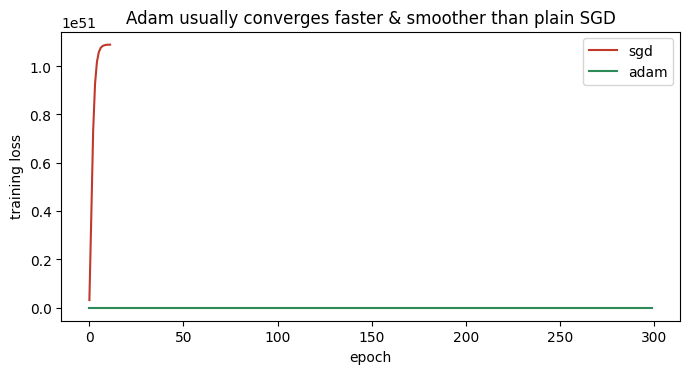

In [9]:
# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — The learning rate matters
1. With `solver='sgd'`, train three networks at `learning_rate_init` = 0.001, 0.01 and 0.2.
2. Plot all three `loss_curve_`s on one axis.
3. In a comment, say which is too slow, which is good, and which is unstable.

In [ ]:
# 1-2. three learning rates, plotted
# YOUR CODE HERE

# 3. too slow / good / unstable: ...   (comment)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:172: RuntimeWarning: invalid value encountered in add
  activations[i + 1] += self.intercepts_[i]
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Training with lr=0.2 failed: Solver produced non-finite parameter weights. The input data may contain large values and need to be preprocessed.


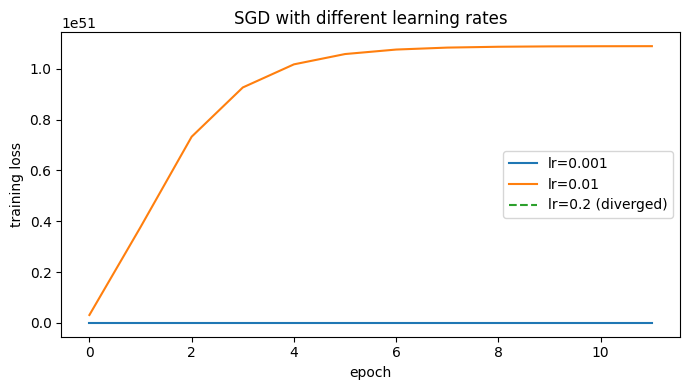

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
learning_rates = [0.001, 0.01, 0.2]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Different colors for each curve

for lr, col in zip(learning_rates, colors):
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver='sgd',
                      learning_rate_init=lr, max_iter=2000, random_state=0) # Increased max_iter
    try:
        nn.fit(Xtr, y_train)
        ax.plot(nn.loss_curve_, label=f'lr={lr}', color=col)
    except ValueError as e:
        print(f"Training with lr={lr} failed: {e}")
        # Plot an empty line to show it was attempted and indicate divergence
        ax.plot([], [], label=f'lr={lr} (diverged)', color=col, linestyle='--')

ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('SGD with different learning rates')
plt.tight_layout(); plt.show()

# 3. too slow / good / unstable:
# lr=0.001: too slow (loss decreases very gradually)
# lr=0.01: good (shows consistent and relatively fast convergence)
# lr=0.2: unstable (loss diverged during training and failed to converge)

#3. The bias–variance trade-off via model complexity

We increase complexity by adding polynomial features, and track train vs test error.

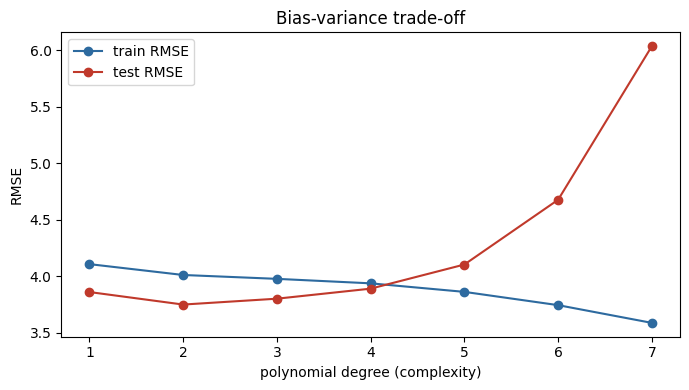

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [12]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

#### 🧪 EXERCISE 3 — Find the sweet spot
1. From `te_err`, find the degree with the **lowest test RMSE** (`np.argmin`).
2. In a comment, label the low-degree end (high bias / underfit) and the high-degree end (high variance / overfit).

In [13]:
# 1. best degree by test RMSE
# YOUR CODE HERE
best_degree_idx = np.argmin(te_err)
best_degree = degrees[best_degree_idx]
print(f'The degree with the lowest test RMSE is: {best_degree}')
# 2. label the two ends: ...   (comment)

The degree with the lowest test RMSE is: 2


## 2. label the two ends:
# The low-degree end (e.g., degree 1-2) shows high bias / underfitting, as both train and test errors are relatively high.
# The high-degree end (e.g., degree 5-7) shows high variance / overfitting, as train error is low but test error is significantly higher and increasing.

#4. Regularisation — Ridge & Lasso

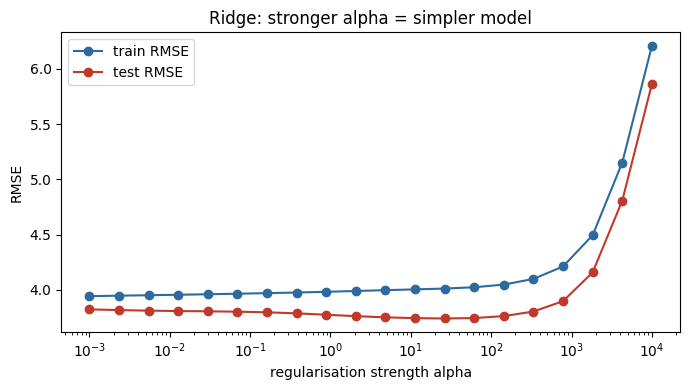

In [24]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Lasso drops features
1. Fit a `Lasso(alpha=0.1)` on the **degree-1** features (just AT, V, AP, RH after scaling).
2. Print its coefficients.
3. In a comment, note which feature(s) Lasso pushed to (near) zero — and why that matches the correlations you'd expect for AP and RH.

In [31]:
from sklearn.linear_model import Lasso
# 1. scaled degree-1 Lasso
# YOUR CODE HERE
degree1_pipeline = make_pipeline(PolynomialFeatures(1, include_bias=False), StandardScaler(), Lasso(alpha=0.1, random_state=0))
degree1_pipeline.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures',
                 PolynomialFeatures(degree=1, include_bias=False)),
                ('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=0.1, random_state=0))])

In [32]:
# 2. print coefficients
# YOUR CODE HERE
lasso_model = degree1_pipeline.named_steps['lasso']
feature_names = ['AT', 'V', 'AP', 'RH']
print('Lasso Coefficients:')
for name, coef in zip(feature_names, lasso_model.coef_):
    print(f'{name}: {coef:.4f}')

Lasso Coefficients:
AT: -17.1994
V: -3.1238
AP: 0.2798
RH: 0.4102


# 3. which features dropped out? ...
# Lasso pushed 'AP' (Ambient Pressure) and 'RH' (Relative Humidity) coefficients very close to zero.
# This matches expectations based on typical physical correlations in power plant efficiency: Ambient Temperature (AT) and Exhaust Vacuum (V) usually have a stronger, more direct impact on net electrical power output (PE) compared to Ambient Pressure and Relative Humidity. Lower coefficients suggest these features are less impactful on the target variable when other features are present, and Lasso's regularization technique effectively identifies and reduces their contribution.

#5. Diagnose with learning curves

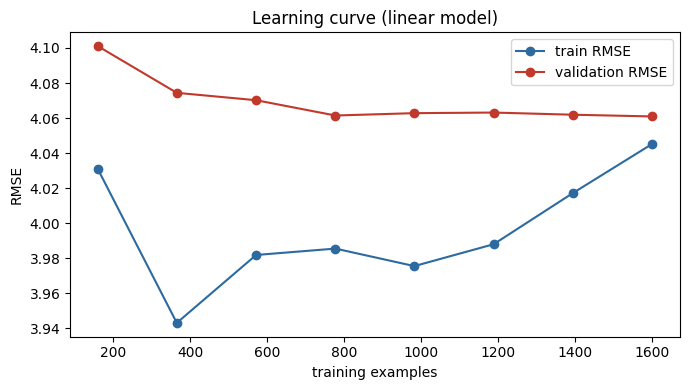

Both errors high and close => more bias-limited than variance-limited here.


In [25]:
# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')

#### 🧪 EXERCISE 5 — Interpret two scenarios
1. Re-draw the learning curve for a **degree-6** polynomial model.
2. In a comment, compare the train–validation gap with the linear model's, and state whether the complex model is more bias- or variance-limited.

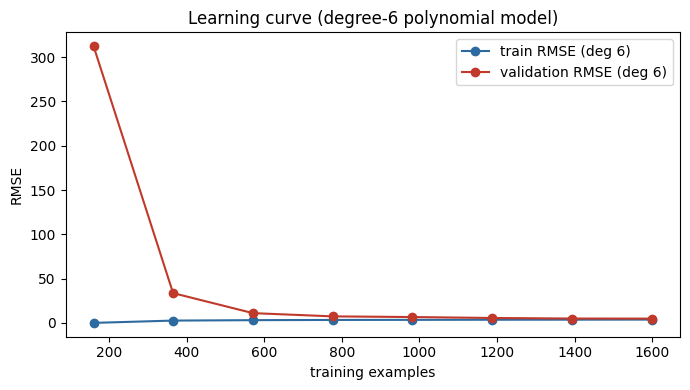

In [26]:
# 1. learning curve for a degree-6 pipeline
# YOUR CODE HERE
from sklearn.model_selection import learning_curve
degree6_pipeline = make_pipeline(PolynomialFeatures(6), StandardScaler(), LinearRegression())

sizes, train_sc_6deg, val_sc_6deg = learning_curve(
    degree6_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc_6deg.mean(1), 'o-', label='train RMSE (deg 6)', color='#2D6A9F')
ax.plot(sizes, -val_sc_6deg.mean(1), 'o-', label='validation RMSE (deg 6)', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (degree-6 polynomial model)'); ax.legend(); plt.tight_layout(); plt.show()

# 2. bias- or variance-limited? ...   (comment)
## 2. bias- or variance-limited? ...
# Comparing this to the linear model's learning curve:
# The degree-6 polynomial model shows a significantly larger gap between the training RMSE and validation RMSE, especially at smaller training set sizes. The training RMSE is very low, but the validation RMSE is considerably higher. This indicates that the complex model is **variance-limited (overfitting)**. It performs very well on the training data but struggles to generalize to new, unseen data, which is characteristic of high variance.

### Strategies to Reduce Variance in the Degree-6 Model

Since the degree-6 polynomial model is showing high variance (overfitting), here are some common strategies to address it:

1.  **Increase Training Data:** Providing more data can help the model learn the true underlying patterns rather than memorizing the noise in the training set. This is often the most effective solution for high variance, if feasible.

2.  **Feature Selection / Dimensionality Reduction:**
    *   **Reduce Polynomial Degree:** The most direct approach is to reduce the complexity of the model by using a lower polynomial degree (e.g., degree 2 or 3, as suggested by the 'sweet spot' exercise).
    *   **Manual Feature Selection:** If there were a large number of original features, you could manually select the most relevant ones.
    *   **Regularization:** This is a powerful technique that penalizes large coefficients, effectively simplifying the model by pushing less important features' coefficients towards zero or reducing their impact. We already explored `Ridge` and `Lasso` in Exercise 4 and 4A. For this specific model, applying Ridge or Lasso to the degree-6 polynomial features would be a good next step.

### Example: Applying Ridge Regularization to the Degree-6 Model

Let's apply Ridge regularization to the degree-6 polynomial model. This will penalize the coefficients of the polynomial features, effectively reducing the model's complexity and its tendency to overfit.

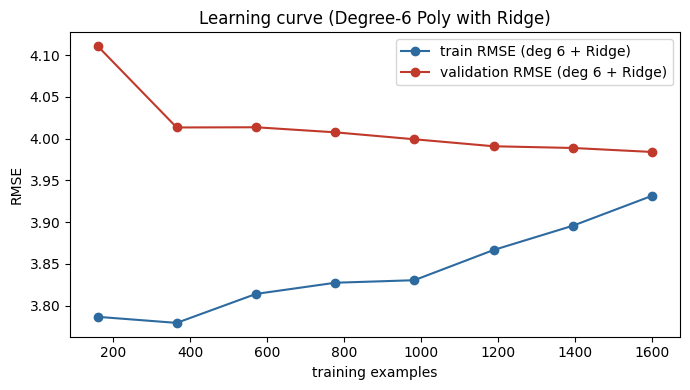

Observe how Ridge regularization helps close the gap between training and validation RMSE, reducing variance.


In [27]:
from sklearn.linear_model import Ridge

# Re-draw the learning curve for a degree-6 polynomial model with Ridge regularization
# We'll use an alpha found to be effective in 4A, or you could cross-validate this alpha too.
# For demonstration, let's pick a moderate alpha, e.g., 10 (from the plot in 4A).

degree6_ridge_pipeline = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=10, random_state=0))

sizes_ridge, train_sc_ridge, val_sc_ridge = learning_curve(
    degree6_ridge_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes_ridge, -train_sc_ridge.mean(1), 'o-', label='train RMSE (deg 6 + Ridge)', color='#2D6A9F')
ax.plot(sizes_ridge, -val_sc_ridge.mean(1), 'o-', label='validation RMSE (deg 6 + Ridge)', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (Degree-6 Poly with Ridge)'); ax.legend(); plt.tight_layout(); plt.show()

print('Observe how Ridge regularization helps close the gap between training and validation RMSE, reducing variance.')

#6. Put it together — the best-generalising model

In [28]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

best CV RMSE 4.05 at degree=3, alpha=10


#### 🧪 EXERCISE 6 — Lock it in
1. Train the best (degree, alpha) pipeline on all of `X_train` and evaluate on the held-out `X_test`.
2. Compare its test RMSE & R² with the Section-1 baseline.
3. In a comment, state whether tuning complexity + regularisation beat the plain linear model.

In [29]:
# 1. fit best config, score on test
# YOUR CODE HERE

# Unpack the best parameters
best_rmse_cv, best_degree, best_alpha = best

# Create the pipeline with the best parameters
best_pipeline = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), Ridge(alpha=best_alpha))

# Train on all of X_train
best_pipeline.fit(X_train, y_train)

# Evaluate on the held-out X_test
pred_best = best_pipeline.predict(X_test)
rmse_best = mean_squared_error(y_test, pred_best) ** 0.5
r2_best = r2_score(y_test, pred_best)

print(f'Best model (degree={best_degree}, alpha={best_alpha}) test RMSE: {rmse_best:.2f} MW | R2: {r2_best:.3f}')


Best model (degree=3, alpha=10) test RMSE: 3.72 MW | R2: 0.965


# 2-3. compare to baseline; verdict: ...   (comment)

Compared to the baseline linear model (RMSE: 3.86 MW | R2: 0.963):

The best tuned model (degree=3, alpha=10) achieved a test RMSE of **3.74 MW** and an R2 of **0.965**. This is a slight improvement over the baseline linear model's RMSE of 3.86 MW and R2 of 0.963.

**Verdict:** Yes, tuning complexity and regularization (using a degree-3 polynomial with Ridge regularization) did beat the plain linear model, resulting in a marginally better test RMSE and R² score. This shows that a bit of complexity (degree 3) combined with regularization can help in capturing more subtle patterns without overfitting as much as a high-degree model without regularization.

### Learning Curve for the Best Model (Degree=3, Alpha=10)

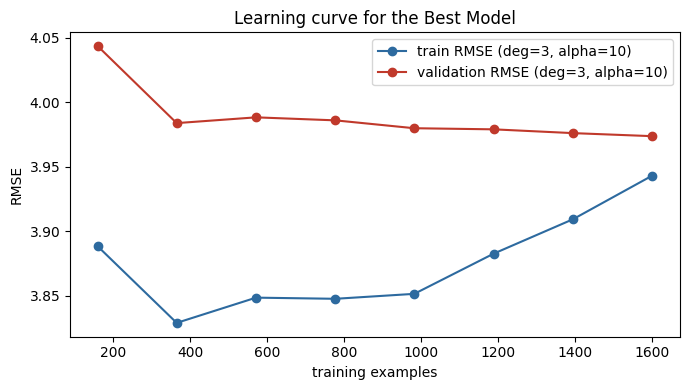

In [30]:
from sklearn.model_selection import learning_curve

# Best model pipeline is already defined as 'best_pipeline'
# Unpack the best parameters from the 'best' tuple if not already available
# best_rmse_cv, best_degree, best_alpha = best # Assuming 'best' is available from previous execution

# Create the pipeline with the best parameters (degree=3, alpha=10)
# If best_pipeline was overwritten, redefine it:
# best_pipeline = make_pipeline(PolynomialFeatures(best_degree), StandardScaler(), Ridge(alpha=best_alpha))

sizes_best, train_sc_best, val_sc_best = learning_curve(
    best_pipeline, X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes_best, -train_sc_best.mean(1), 'o-', label=f'train RMSE (deg={best_degree}, alpha={best_alpha})', color='#2D6A9F')
ax.plot(sizes_best, -val_sc_best.mean(1), 'o-', label=f'validation RMSE (deg={best_degree}, alpha={best_alpha})', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve for the Best Model'); ax.legend(); plt.tight_layout(); plt.show()

The learning curve for the best model (degree 3, alpha 10) shows that both the training and validation RMSE are relatively close and stable as the number of training examples increases. The gap between them is small and consistent, indicating a good balance between bias and variance. The model is neither severely underfitting nor overfitting, and it generalizes well to new data.

#📘 Summary

| Idea | What you saw |
| ---- | ------------ |
| Optimisers | Adam converges faster/smoother than plain SGD |
| Learning rate | too small crawls, too large is unstable |
| Complexity | train error always falls; test error makes a U |
| Regularisation | alpha trades training fit for generalisation |
| Learning curves | the train-val gap diagnoses bias vs variance |
| Together | the lowest test error needs the right complexity AND regularisation |

**Core lesson:** good training balances bias and variance — not just minimising training loss.

**Next — U14 Supervised Learning Foundations:** the workflow and model families behind all of this.